In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

folder = "/content/drive/MyDrive/NN"

print("Files in folder:")
for file in os.listdir(folder):
    print(file)

Files in folder:
bank-data.zip
Archive.zip


In [6]:
import os

zip_path = "/content/drive/MyDrive/NN/Archive.zip"

size_gb = os.path.getsize(zip_path) / (1024 ** 3)

print(f"ZIP file size: {size_gb:.2f} GB")

ZIP file size: 1.14 GB


In [7]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/NN/Archive.zip"
extract_path = "/content/chest_xray"

print("Starting extraction...")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Starting extraction...
Extraction completed!


In [8]:
import os

print("Contents of /content/chest_xray:")

for item in os.listdir("/content/chest_xray"):
    print(item)

Contents of /content/chest_xray:
test
__MACOSX
train
val


In [10]:
from pathlib import Path

base = Path("/content/chest_xray")

print("Searching for dataset folders...\n")

for folder_name in ["train", "test", "val"]:
    matches = list(base.rglob(folder_name))

    print(f"{folder_name}:")
    for match in matches:
        print("  ", match)

Searching for dataset folders...

train:
   /content/chest_xray/train
   /content/chest_xray/__MACOSX/train
test:
   /content/chest_xray/test
   /content/chest_xray/__MACOSX/test
val:
   /content/chest_xray/val


In [11]:
from pathlib import Path

base = Path("/content/chest_xray")

train_matches = list(base.rglob("train"))
test_matches = list(base.rglob("test"))
val_matches = list(base.rglob("val"))

if not train_matches:
    raise FileNotFoundError("Could not find the train folder.")

if not test_matches:
    raise FileNotFoundError("Could not find the test folder.")

if not val_matches:
    raise FileNotFoundError("Could not find the val folder.")

train_dir = train_matches[0]
test_dir = test_matches[0]
val_dir = val_matches[0]

print("Train:", train_dir)
print("Test :", test_dir)
print("Val  :", val_dir)

Train: /content/chest_xray/train
Test : /content/chest_xray/test
Val  : /content/chest_xray/val


In [12]:
import os

print("Training classes:")
print(os.listdir(train_dir))

print("\nTesting classes:")
print(os.listdir(test_dir))

print("\nValidation classes:")
print(os.listdir(val_dir))

Training classes:
['NORMAL', '.DS_Store', 'PNEUMONIA']

Testing classes:
['NORMAL', '.DS_Store', 'PNEUMONIA']

Validation classes:
['NORMAL', 'PNEUMONIA']


In [13]:
from pathlib import Path

def count_images(folder):
    extensions = {".jpg", ".jpeg", ".png"}

    counts = {}

    for class_folder in folder.iterdir():
        if class_folder.is_dir():
            count = sum(
                1 for file in class_folder.rglob("*")
                if file.suffix.lower() in extensions
            )
            counts[class_folder.name] = count

    return counts

print("TRAIN:")
print(count_images(train_dir))

print("\nVALIDATION:")
print(count_images(val_dir))

print("\nTEST:")
print(count_images(test_dir))

TRAIN:
{'NORMAL': 1341, 'PNEUMONIA': 3875}

VALIDATION:
{'NORMAL': 8, 'PNEUMONIA': 8}

TEST:
{'NORMAL': 234, 'PNEUMONIA': 390}


In [14]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


In [16]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

print("Training dataset loaded.")
print("Classes:", train_ds.class_names)

Found 5216 files belonging to 2 classes.
Training dataset loaded.
Classes: ['NORMAL', 'PNEUMONIA']


In [17]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Validation dataset loaded.")
print("Classes:", val_ds.class_names)

Found 16 files belonging to 2 classes.
Validation dataset loaded.
Classes: ['NORMAL', 'PNEUMONIA']


In [18]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Test dataset loaded.")
print("Classes:", test_ds.class_names)

Found 624 files belonging to 2 classes.
Test dataset loaded.
Classes: ['NORMAL', 'PNEUMONIA']


In [19]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


In [20]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
], name="data_augmentation")

print("Data augmentation created.")

Data augmentation created.


In [26]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get class names directly from the training folders
class_names = sorted([
    folder.name
    for folder in train_dir.iterdir()
    if folder.is_dir()
])

print("Class names:", class_names)

# Count images in each class
class_counts = {}

for class_name in class_names:
    class_folder = train_dir / class_name

    count = sum(
        1
        for file in class_folder.rglob("*")
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
    )

    class_counts[class_name] = count

print("\nTraining image counts:")
print(class_counts)

# Create labels based on the number of images in each class
labels = []

for class_index, class_name in enumerate(class_names):
    labels.extend([class_index] * class_counts[class_name])

labels = np.array(labels)

# Find unique class labels
classes = np.unique(labels)

# Calculate balanced class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=labels
)

# Create dictionary for TensorFlow
class_weights = {
    int(class_index): float(weight)
    for class_index, weight in zip(classes, weights)
}

print("\nClass weights:")
print(class_weights)



Class names: ['NORMAL', 'PNEUMONIA']

Training image counts:
{'NORMAL': 1341, 'PNEUMONIA': 3875}

Class weights:
{0: 1.9448173005219984, 1: 0.6730322580645162}


In [27]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(256, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,441 (1.61 MB)

 Trainable params: 421,441 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [29]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "/content/best_pneumonia_cnn.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Callbacks created.")

Callbacks created.


In [30]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 217ms/step - accuracy: 0.4147 - auc: 0.6616 - loss: 0.6757 - precision: 0.9135 - recall: 0.2343 - val_accuracy: 0.5625 - val_auc: 0.7109 - val_loss: 0.6591 - val_precision: 1.0000 - val_recall: 0.1250 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 243ms/step - accuracy: 0.7141 - auc: 0.8182 - loss: 0.5444 - precision: 0.9165 - recall: 0.6769 - val_accuracy: 0.6250 - val_auc: 0.7422 - val_loss: 0.5572 - val_precision: 0.6667 - val_recall: 0.5000 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 36s 221ms/step - accuracy: 0.8016 - auc: 0.8881 - loss: 0.4313 - precision: 0.9385 - recall: 0.7843 - val_accuracy: 0.7500 - val_auc: 0.7812 - val_loss: 0.5635 - val_precision: 1.0000 - val_recall: 0.5000 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.8399 - auc: 0.9131 - loss: 0.3747 - precision: 0.9545 - recall: 0.8237 - val_accuracy: 0.6875 - val_auc: 0.8516 

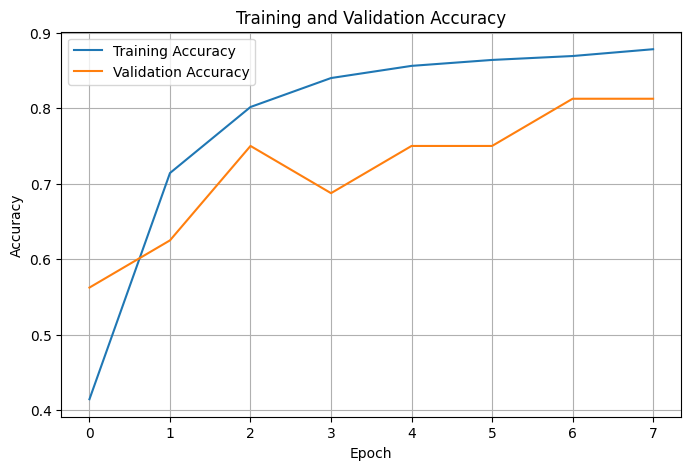

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

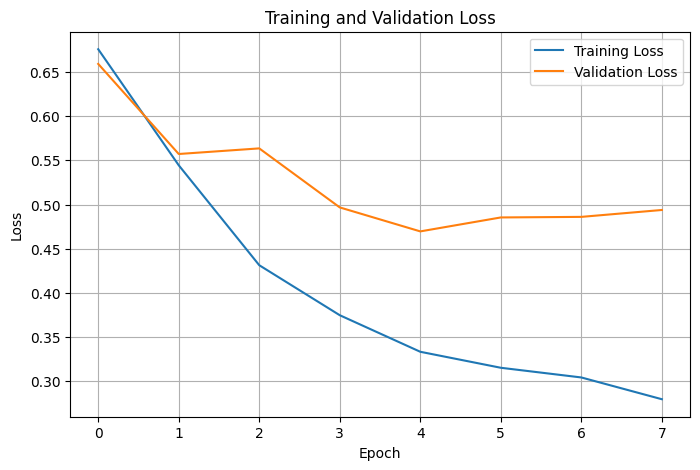

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [33]:
test_results = model.evaluate(test_ds, verbose=1)

print("\nTest results:")

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step - accuracy: 0.7981 - auc: 0.9150 - loss: 0.4645 - precision: 0.9459 - recall: 0.7179

Test results:
loss: 0.4645
compile_metrics: 0.7981


In [34]:
y_true = []
y_prob = []

for images, labels in test_ds:
    probabilities = model.predict(images, verbose=0)

    y_true.extend(labels.numpy().flatten())
    y_prob.extend(probabilities.flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

print("Predictions generated.")
print("Number of test images:", len(y_true))

Predictions generated.
Number of test images: 624


In [36]:
from sklearn.metrics import classification_report

# Get class names directly from the test folder
class_names = sorted([
    folder.name
    for folder in test_dir.iterdir()
    if folder.is_dir()
])

# Print classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)



              precision    recall  f1-score   support

      NORMAL       0.66      0.93      0.78       234
   PNEUMONIA       0.95      0.72      0.82       390

    accuracy                           0.80       624
   macro avg       0.81      0.82      0.80       624
weighted avg       0.84      0.80      0.80       624



In [37]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[218  16]
 [110 280]]


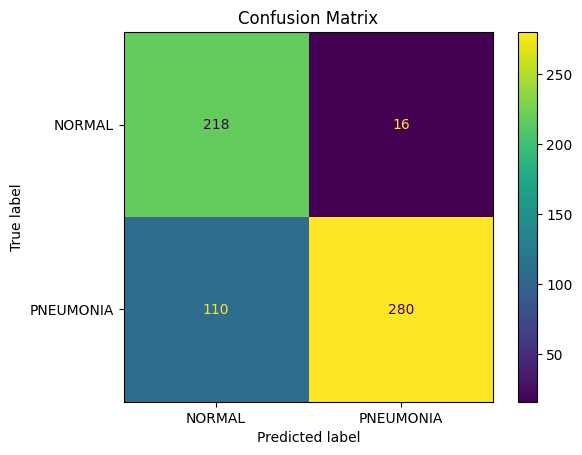

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Get class names directly from the test folder
class_names = sorted([
    folder.name
    for folder in test_dir.iterdir()
    if folder.is_dir()
])

# Create confusion matrix display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()



In [40]:
auc_score = roc_auc_score(y_true, y_prob)

print(f"ROC-AUC: {auc_score:.4f}")

ROC-AUC: 0.9151


In [41]:
model_path = "/content/drive/MyDrive/NN/pneumonia_cnn_model.keras"

model.save(model_path)

print("Model saved successfully!")
print(model_path)

Model saved successfully!
/content/drive/MyDrive/NN/pneumonia_cnn_model.keras


In [43]:
import json

results = {
    "test_accuracy": float(test_results[1]),
    "test_auc": float(test_results[2]),
    "test_precision": float(test_results[3]),
    "test_recall": float(test_results[4]),
    "roc_auc": float(auc_score)
}

results_path = "/content/drive/MyDrive/NN/results.json"

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print("Results saved to:")
print(results_path)

print("\nResults:")
print(json.dumps(results, indent=4))

Results saved to:
/content/drive/MyDrive/NN/results.json

Results:
{
    "test_accuracy": 0.7980769276618958,
    "test_auc": 0.9149791598320007,
    "test_precision": 0.9459459185600281,
    "test_recall": 0.7179487347602844,
    "roc_auc": 0.9151106728029805
}


In [45]:
import json

results = {
    "test_accuracy": float(test_results[1]),
    "test_auc": float(test_results[2]),
    "test_precision": float(test_results[3]),
    "test_recall": float(test_results[4]),
    "roc_auc": float(auc_score)
}

results_path = "/content/drive/MyDrive/NN/results.json"

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print("Results saved to:")
print(results_path)

print("\nResults:")
print(json.dumps(results, indent=4))

Results saved to:
/content/drive/MyDrive/NN/results.json

Results:
{
    "test_accuracy": 0.7980769276618958,
    "test_auc": 0.9149791598320007,
    "test_precision": 0.9459459185600281,
    "test_recall": 0.7179487347602844,
    "roc_auc": 0.9151106728029805
}
